In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def extract_best(df):
    chosen_configurations = []
    for recall_cut in np.arange(0.9, 1.01, 0.01):
        chosen_configurations.append(df[df.Recall > recall_cut].sort_values("Query Time (microsecs)").head(1))
    df = pd.concat(chosen_configurations)
    return df


In [4]:
log_files = {
    "f16" : "/home/cosimorulli/next_develop_seismic/martinos_patch/seismic_private/grid_search_cocondenser_2025-10-06_10:36:07.500100/building_combination_0_2025-10-06_10:36:07/report.tsv",
    "partitioned_f16" : "/home/cosimorulli/next_develop_seismic/martinos_patch/seismic_private/grid_search_cocondenser_partitioned_f16_2025-10-06_08:43:00.570205/building_combination_0_2025-10-06_08:43:00/report.tsv", 
    "partitioned_f8": "/home/cosimorulli/next_develop_seismic/martinos_patch/seismic_private/grid_search_cocondenser_partitioned_f8_2025-10-06_09:14:14.626621/building_combination_0_2025-10-06_09:14:14/report.tsv",
    "streamvbyte": "/home/cosimorulli/next_develop_seismic/martinos_patch/seismic_private/grid_search_cocondenser_streamvbyte_f8_2025-10-06_10:09:20.725532/building_combination_0_2025-10-06_10:09:20/report.tsv",
    "streamvbyte-v2": "/home/cosimorulli/next_develop_seismic/martinos_patch/seismic_private/grid_search_cocondenser_streamvbyte_f8_diff_target_cpu_2025-10-06_14:35:22.031046/building_combination_0_2025-10-06_14:35:22/report.tsv"
}

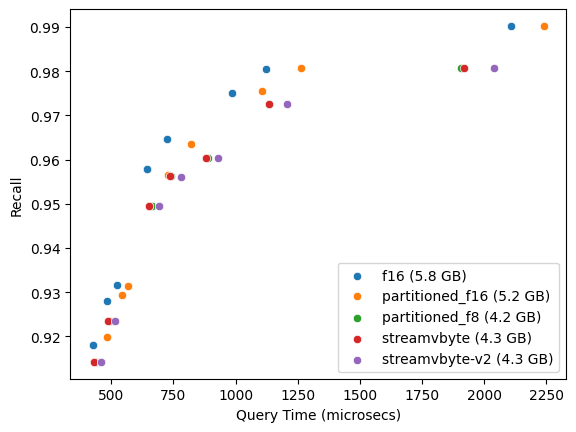

In [5]:
all_df = []

for name, file_path in log_files.items():
    current_df = extract_best(pd.read_csv(file_path, sep="\t"))
    mem_usage = current_df["Memory Usage (Bytes)"].values[0] / 1024**3
    current_df['name'] = name
    all_df.append(current_df)
    sns.scatterplot(data=current_df, x = "Query Time (microsecs)", y="Recall", label=f"{name} ({round(mem_usage, 1)} GB)")

plt.legend()
all_df = pd.concat(all_df)

In [6]:
all_df[all_df.name == 'partitioned_f8']

,Subsection,Query Time (microsecs),Recall,RR@10,Memory Usage (Bytes),Building Time (secs),name
14,combination_15,439,0.914212,0.378359,4531762589,238,partitioned_f8
14,combination_15,439,0.914212,0.378359,4531762589,238,partitioned_f8
23,combination_24,496,0.923467,0.378490,4531762589,238,partitioned_f8
12,combination_13,662,0.949470,0.380517,4531762589,238,partitioned_f8
13,combination_14,662,0.949470,0.380517,4531762589,238,partitioned_f8
21,combination_22,738,0.956175,0.380540,4531762589,238,partitioned_f8
52,combination_53,889,0.960430,0.380618,4531762589,238,partitioned_f8
19,combination_20,1134,0.972536,0.381893,4531762589,238,partitioned_f8
33,combination_34,1907,0.980731,0.382002,4531762589,238,partitioned_f8


In [45]:
all_df[all_df.name == 'streamvbyte']

,Subsection,Query Time (microsecs),Recall,RR@10,Memory Usage (Bytes),Building Time (secs),name
14,combination_15,431,0.914284,0.378359,4610633505,206,streamvbyte
14,combination_15,431,0.914284,0.378359,4610633505,206,streamvbyte
22,combination_23,487,0.923524,0.378490,4610633505,206,streamvbyte
13,combination_14,652,0.949470,0.380517,4610633505,206,streamvbyte
13,combination_14,652,0.949470,0.380517,4610633505,206,streamvbyte
20,combination_21,735,0.956175,0.380540,4610633505,206,streamvbyte
52,combination_53,879,0.960430,0.380618,4610633505,206,streamvbyte
19,combination_20,1133,0.972564,0.381893,4610633505,206,streamvbyte
32,combination_33,1920,0.980759,0.382002,4610633505,206,streamvbyte
